# Credit Card Fraud Detection — Model Performance Comparison
**Author: Slok Patel**

This notebook evaluates and compares the performance of all trained models:
- Logistic Regression (Alyssa Tu)
- Random Forest (Humayra Rashid)
- XGBoost (John Lopez)
- ANN — Artificial Neural Network (Brian Andrade)

Metrics: Precision, Recall, AUPRC (Area Under Precision-Recall Curve)

## 1. Install & Import Libraries

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

Place `creditcard.csv` in the same folder as this notebook before running.

In [9]:
import pandas as pd

df = pd.read_csv('C:/Users/slokp/Downloads/SlokPCreditCardFraud/creditcard.csv')
print(f'Loaded from local file. Shape: {df.shape}')

Loaded from local file. Shape: (284807, 31)


In [10]:
print('Dataset Overview:')
print(f'  Total transactions : {len(df):,}')
print(f'  Fraudulent         : {df["Class"].sum():,} ({df["Class"].mean()*100:.3f}%)')
print(f'  Legitimate         : {(df["Class"]==0).sum():,}')
df.head()

Dataset Overview:
  Total transactions : 284,807
  Fraudulent         : 492 (0.173%)
  Legitimate         : 284,315


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Preprocessing

Standardize `Amount` and `Time`. All 4 models use the same train/test split for a fair comparison.

In [11]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df_model = df.drop(columns=['Time', 'Amount'])

X = df_model.drop('Class', axis=1)
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples ({y_train.sum()} fraud)')
print(f'Test set:     {X_test.shape[0]:,} samples ({y_test.sum()} fraud)')

Training set: 227,845 samples (394 fraud)
Test set:     56,962 samples (98 fraud)


## 4. Train All Models

In [12]:
# --- Logistic Regression (Alyssa Tu) ---
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)
print('  Done.')

Training Logistic Regression...
  Done.


In [13]:
# --- Random Forest (Humayra Rashid) ---
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('  Done.')

Training Random Forest...
  Done.


In [14]:
# --- XGBoost (John Lopez) ---
print('Training XGBoost...')
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
print('  Done.')

Training XGBoost...
  Done.


In [15]:
# --- ANN - Artificial Neural Network (Brian Andrade) ---
# Backpropagation + Gradient Descent Optimization
print('Training ANN...')

class_weight_dict = {
    0: 1.0,
    1: neg_count / pos_count
}

ann_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)
print('  Done.')

Training ANN...
Epoch 1/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9490 - loss: 0.7565 - val_accuracy: 0.9828 - val_loss: 0.1044
Epoch 2/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9565 - loss: 0.4231 - val_accuracy: 0.9539 - val_loss: 0.1528
Epoch 3/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9592 - loss: 0.3413 - val_accuracy: 0.9806 - val_loss: 0.0638
Epoch 4/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9650 - loss: 0.2907 - val_accuracy: 0.9808 - val_loss: 0.0629
Epoch 5/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9656 - loss: 0.2702 - val_accuracy: 0.9686 - val_loss: 0.0828
Epoch 6/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9650 - loss: 0.2704 - val_accuracy: 0.9809 - val_loss: 0.0580
Epoch 7/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9662 - loss: 0.2585 - val_accuracy: 0.9798 - val_loss: 0.0663
Epoch 8/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9696 - loss: 0.2296 - 

## 5. Evaluate Models Using Precision & Recall

In [16]:
sklearn_models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model
}

results = {}

for name, model in sklearn_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    auprc     = average_precision_score(y_test, y_proba)
    f1        = 2 * (precision * recall) / (precision + recall + 1e-9)

    results[name] = {
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'AUPRC':     round(auprc, 4),
        'F1 Score':  round(f1, 4),
        'y_proba':   y_proba
    }

    print(f'\n{name}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  AUPRC     : {auprc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')

# ANN
ann_proba = ann_model.predict(X_test).flatten()
ann_pred  = (ann_proba >= 0.5).astype(int)

ann_precision = precision_score(y_test, ann_pred)
ann_recall    = recall_score(y_test, ann_pred)
ann_auprc     = average_precision_score(y_test, ann_proba)
ann_f1        = 2 * (ann_precision * ann_recall) / (ann_precision + ann_recall + 1e-9)

results['ANN'] = {
    'Precision': round(ann_precision, 4),
    'Recall':    round(ann_recall, 4),
    'AUPRC':     round(ann_auprc, 4),
    'F1 Score':  round(ann_f1, 4),
    'y_proba':   ann_proba
}

print(f'\nANN (Brian Andrade)')
print(f'  Precision : {ann_precision:.4f}')
print(f'  Recall    : {ann_recall:.4f}')
print(f'  AUPRC     : {ann_auprc:.4f}')
print(f'  F1 Score  : {ann_f1:.4f}')


Logistic Regression
  Precision : 0.0609
  Recall    : 0.9184
  AUPRC     : 0.7189
  F1 Score  : 0.1141

Random Forest
  Precision : 0.9610
  Recall    : 0.7551
  AUPRC     : 0.8653
  F1 Score  : 0.8457

XGBoost
  Precision : 0.7593
  Recall    : 0.8367
  AUPRC     : 0.8675
  F1 Score  : 0.7961
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

ANN (Brian Andrade)
  Precision : 0.1019
  Recall    : 0.8980
  AUPRC     : 0.6852
  F1 Score  : 0.1830


## 6. Compute AUPRC for Each Model (Precision-Recall Curves)

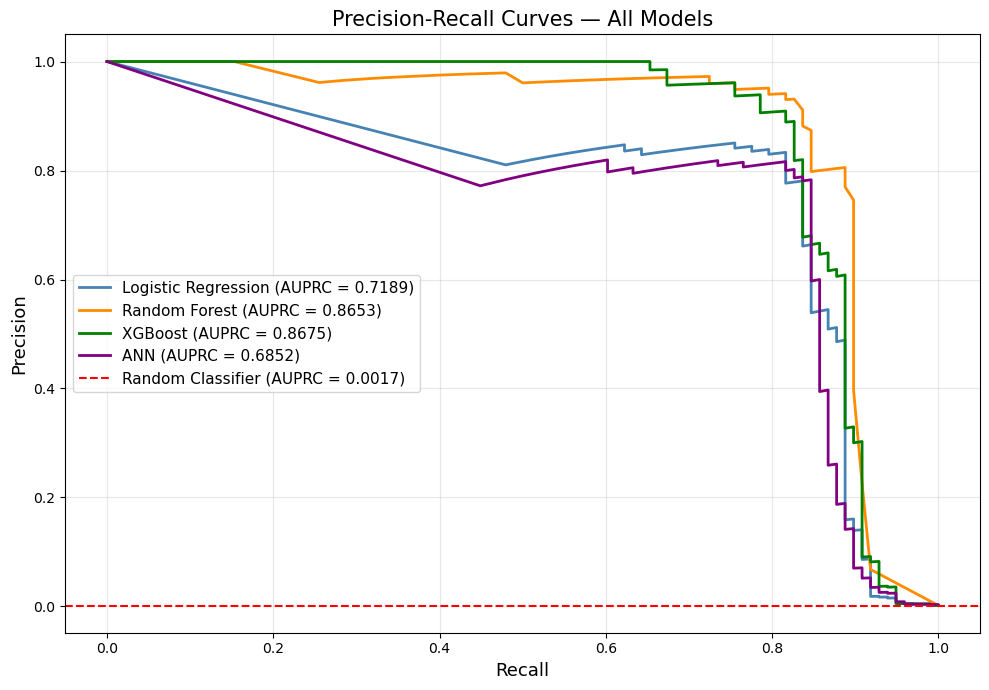

Figure saved as precision_recall_curves.png


In [17]:
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'purple']

for (name, res), color in zip(results.items(), colors):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(rec_vals, prec_vals, label=f"{name} (AUPRC = {res['AUPRC']:.4f})", color=color, lw=2)

baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Random Classifier (AUPRC = {baseline:.4f})')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves — All Models', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()
print('Figure saved as precision_recall_curves.png')

## 7. Compare Results Across All Models

In [18]:
summary_df = pd.DataFrame({
    name: {
        'Precision': res['Precision'],
        'Recall':    res['Recall'],
        'AUPRC':     res['AUPRC'],
        'F1 Score':  res['F1 Score']
    }
    for name, res in results.items()
}).T

print('\n===== MODEL COMPARISON SUMMARY =====')
print(summary_df.to_string())
summary_df


===== MODEL COMPARISON SUMMARY =====
                     Precision  Recall   AUPRC  F1 Score
Logistic Regression     0.0609  0.9184  0.7189    0.1141
Random Forest           0.9610  0.7551  0.8653    0.8457
XGBoost                 0.7593  0.8367  0.8675    0.7961
ANN                     0.1019  0.8980  0.6852    0.1830


,Precision,Recall,AUPRC,F1 Score
Logistic Regression,0.0609,0.9184,0.7189,0.1141
Random Forest,0.9610,0.7551,0.8653,0.8457
XGBoost,0.7593,0.8367,0.8675,0.7961
ANN,0.1019,0.8980,0.6852,0.1830


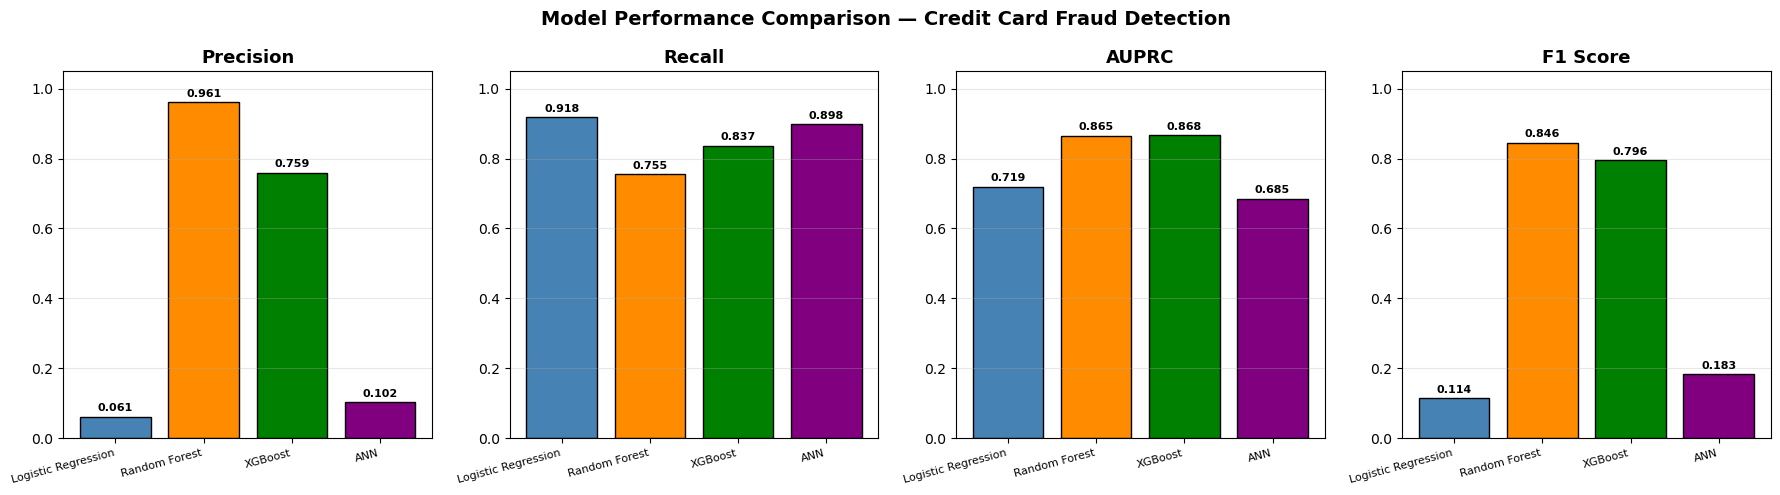

Figure saved as model_comparison_bar.png


In [19]:
metrics = ['Precision', 'Recall', 'AUPRC', 'F1 Score']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'green', 'purple']

for ax, metric in zip(axes, metrics):
    values = [results[m][metric] for m in results]
    bars = ax.bar(list(results.keys()), values, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(list(results.keys()), rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison — Credit Card Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()
print('Figure saved as model_comparison_bar.png')

## 8. Select Best-Performing Model

For fraud detection, **AUPRC is the primary metric** because the dataset is highly imbalanced (~0.17% fraud). A high AUPRC means the model correctly ranks fraudulent transactions above legitimate ones across all decision thresholds.

In [20]:
best_model_name = max(results, key=lambda m: results[m]['AUPRC'])
best = results[best_model_name]

print('=' * 50)
print(f'BEST MODEL: {best_model_name}')
print('=' * 50)
print(f'  Precision : {best["Precision"]:.4f}')
print(f'  Recall    : {best["Recall"]:.4f}')
print(f'  AUPRC     : {best["AUPRC"]:.4f}')
print(f'  F1 Score  : {best["F1 Score"]:.4f}')
print()
print('Reasoning:')
print(f'  {best_model_name} achieves the highest AUPRC ({best["AUPRC"]:.4f}), meaning it')
print('  best distinguishes fraud from legitimate transactions across all')
print('  classification thresholds — critical for a severely imbalanced dataset.')

BEST MODEL: XGBoost
  Precision : 0.7593
  Recall    : 0.8367
  AUPRC     : 0.8675
  F1 Score  : 0.7961

Reasoning:
  XGBoost achieves the highest AUPRC (0.8675), meaning it
  best distinguishes fraud from legitimate transactions across all
  classification thresholds — critical for a severely imbalanced dataset.



Classification Report — XGBoost:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



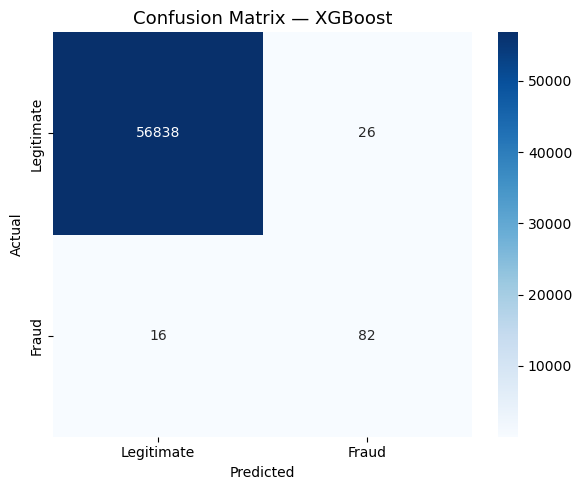


True Positives  (Fraud caught):  82
False Negatives (Fraud missed):  16
False Positives (False alarms):  26
True Negatives  (Legit correct): 56838


In [21]:
# Confusion matrix for best model
if best_model_name == 'ANN':
    y_pred_best = ann_pred
else:
    best_model_obj = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}[best_model_name]
    y_pred_best = best_model_obj.predict(X_test)

print(f'\nClassification Report — {best_model_name}:')
print(classification_report(y_test, y_pred_best, target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Positives  (Fraud caught):  {tp}')
print(f'False Negatives (Fraud missed):  {fn}')
print(f'False Positives (False alarms):  {fp}')
print(f'True Negatives  (Legit correct): {tn}')

## 9. Summary

All 4 models were evaluated on the same test set using precision, recall, AUPRC, and F1 score.
AUPRC was chosen as the primary selection metric due to the severe class imbalance in the dataset (~0.17% fraud).
The best-performing model was automatically selected based on the highest AUPRC score.

**Models compared:**
- Logistic Regression (Alyssa Tu)
- Random Forest (Humayra Rashid)
- XGBoost (John Lopez)
- ANN / Neural Network (Brian Andrade)